In [1]:
import pandas as pd

# Wczytaj dane
df = pd.read_excel('../data/raw/overnight_stays_arrivals_1998.xlsx')

# Podgląd
print(df.shape)
df.head(10)

(68, 60)


,Overnight stays and arrivals in hotels 1998-,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,1998,NaN,1999,NaN,2000,NaN,2001,NaN,...,2022,NaN,2023,NaN,2024,NaN,2025,NaN,2026,NaN
2,NaN,NaN,Arrivals,Overnight stays,Arrivals,Overnight stays,Arrivals,Overnight stays,Arrivals,Overnight stays,...,Arrivals,Overnight stays,Arrivals,Overnight stays,Arrivals,Overnight stays,Arrivals,Overnight stays,Arrivals,Overnight stays
3,Total,Total,347943,693027,360125,728992,367661,757894,376184,771522,...,2798250,4731682,3173682,5263884,3255858,5268662,3090454,5444463,..,..
4,NaN,Icelanders,115683,179778,112776,175749,108382,172122,95871,147714,...,480310,717678,456792,674730,564157,799063,408563,578869,..,..
5,NaN,Foreigners,232260,513249,247349,553243,259279,585772,280313,623808,...,2317940,4014004,2716890,4589154,2691701,4469599,2681891,4865594,..,..
6,January,Total,11011,22942,12157,25955,12676,28336,13312,29685,...,80354,166574,151685,312739,140171,287990,157518,294144,145566,277722
7,NaN,Icelanders,6585,10537,6488,10027,6234,10568,6090,9405,...,16796,29054,26094,43822,20509,32907,26319,37715,20476,28880
8,NaN,Foreigners,4426,12405,5669,15928,6442,17768,7222,20280,...,63558,137520,125591,268917,119662,255083,131199,256429,125090,248842
9,February,Total,16321,33949,18150,38801,19066,40034,18709,42705,...,136283,280409,190822,372895,216418,384489,186237,369029,222144,388956


In [2]:
# Wczytaj ponownie z prawidłowymi nagłówkami
df = pd.read_excel('../data/raw/overnight_stays_arrivals_1998.xlsx', 
                   header=[1, 2],  # dwa poziomy nagłówków
                   index_col=[0, 1])  # dwie kolumny indeksu

df.head(10)

Unnamed: 2_level_0 Unnamed: 3_level_0 Unnamed: 4_level_0  \
                                  1998               1998               1999   
nan      nan                  Arrivals    Overnight stays           Arrivals   
Total    Total                  347943             693027             360125   
         Icelanders             115683             179778             112776   
         Foreigners             232260             513249             247349   
January  Total                   11011              22942              12157   
         Icelanders               6585              10537               6488   
         Foreigners               4426              12405               5669   
February Total                   16321              33949              18150   
         Icelanders               9080              14427               9127   
         Foreigners               7241              19522               9023   

                    Unnamed: 5_level_0 Unnamed: 6_level_0 Unnamed: 7_level_0  \
                                  1999               2000               2000   
nan      nan           Overnight stays           Arrivals    Overnight stays   
Total    Total                  728992             367661             757894   
         Icelanders             175749             108382             172122   
         Foreigners             553243             259279             585772   
January  Total                   25955              12676              28336   
         Icelanders              10027               6234              10568   
         Foreigners              15928               6442              17768   
February Total                   38801              19066              40034   
         Icelanders              14646               9124              13872   
         Foreigners              24155               9942              26162   

                    Unnamed: 8_level_0 Unnamed: 9_level_0 Unnamed: 10_level_0  \
                                  2001               2001                2002   
nan      nan                  Arrivals    Overnight stays            Arrivals   
Total    Total                  376184             771522              394021   
         Icelanders              95871             147714              101759   
         Foreigners             280313             623808              292262   
January  Total                   13312              29685               13777   
         Icelanders               6090               9405                5744   
         Foreigners               7222              20280                8033   
February Total                   18709              42705               20413   
         Icelanders               7129              11334                8741   
         Foreigners              11580              31371               11672   

                    Unnamed: 11_level_0  ... Unnamed: 50_level_0  \
                                   2002  ...                2022   
nan      nan            Overnight stays  ...            Arrivals   
Total    Total                   802108  ...             2798250   
         Icelanders              159111  ...              480310   
         Foreigners              642997  ...             2317940   
January  Total                    31401  ...               80354   
         Icelanders                8912  ...               16796   
         Foreigners               22489  ...               63558   
February Total                    47077  ...              136283   
         Icelanders               14096  ...               28664   
         Foreigners               32981  ...              107619   

                    Unnamed: 51_level_0 Unnamed: 52_level_0  \
                                   2022                2023   
nan      nan            Overnight stays            Arrivals   
Total    Total                  4731682             3173682   
         Icelanders              717678              456

In [4]:
df_raw = pd.read_excel('../data/raw/overnight_stays_arrivals_1998.xlsx', header=None)

years = df_raw.iloc[1, 2:].ffill()
units = df_raw.iloc[2, 2:]

data = df_raw.iloc[3:].copy()
data.columns = ['Month', 'Citizenship'] + [f"{str(y).replace('.0','')}_{u}" for y, u in zip(years, units)]
data['Month'] = data['Month'].ffill()
data = data.dropna(subset=['Citizenship'])

print(data.shape)
data.head(10)

(39, 60)


,Month,Citizenship,nan_1998,nan_nan,nan_1999,nan_nan,nan_2000,nan_nan,nan_2001,nan_nan,...,nan_2022,nan_nan,nan_2023,nan_nan,nan_2024,nan_nan,nan_2025,nan_nan,nan_2026,nan_nan
4,Total,Total,347943,693027,360125,728992,367661,757894,376184,771522,...,2798250,4731682,3173682,5263884,3255858,5268662,3090454,5444463,..,..
5,Total,Icelanders,115683,179778,112776,175749,108382,172122,95871,147714,...,480310,717678,456792,674730,564157,799063,408563,578869,..,..
6,Total,Foreigners,232260,513249,247349,553243,259279,585772,280313,623808,...,2317940,4014004,2716890,4589154,2691701,4469599,2681891,4865594,..,..
7,January,Total,11011,22942,12157,25955,12676,28336,13312,29685,...,80354,166574,151685,312739,140171,287990,157518,294144,145566,277722
8,January,Icelanders,6585,10537,6488,10027,6234,10568,6090,9405,...,16796,29054,26094,43822,20509,32907,26319,37715,20476,28880
9,January,Foreigners,4426,12405,5669,15928,6442,17768,7222,20280,...,63558,137520,125591,268917,119662,255083,131199,256429,125090,248842
10,February,Total,16321,33949,18150,38801,19066,40034,18709,42705,...,136283,280409,190822,372895,216418,384489,186237,369029,222144,388956
11,February,Icelanders,9080,14427,9127,14646,9124,13872,7129,11334,...,28664,50648,28246,49638,31887,48633,25328,39074,27201,38996
12,February,Foreigners,7241,19522,9023,24155,9942,26162,11580,31371,...,107619,229761,162576,323257,184531,335856,160909,329955,194943,349960
13,March,Total,22374,48380,23154,51084,26019,59092,27379,63152,...,171798,334675,233462,424703,256870,439640,231807,420034,263656,431965


In [5]:
df_raw = pd.read_excel('../data/raw/overnight_stays_arrivals_1998.xlsx', header=None)

# Sprawdź pierwsze 4 wiersze
df_raw.iloc[:4, :6]

,0,1,2,3,4,5
0,Overnight stays and arrivals in hotels 1998-,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1998,NaN,1999,NaN
3,NaN,NaN,Arrivals,Overnight stays,Arrivals,Overnight stays


In [6]:
df_raw = pd.read_excel('../data/raw/overnight_stays_arrivals_1998.xlsx', header=None)

# Wyciągnij lata i jednostki z właściwych wierszy
years = df_raw.iloc[2, 2:].ffill()
units = df_raw.iloc[3, 2:]

# Dane od wiersza 4
data = df_raw.iloc[4:].copy()
data.columns = ['Month', 'Citizenship'] + [f"{str(y).replace('.0','')}_{u}" for y, u in zip(years, units)]
data['Month'] = data['Month'].ffill()
data = data.dropna(subset=['Citizenship'])
data = data.reset_index(drop=True)

print(data.shape)
data.head(9)


(39, 60)


,Month,Citizenship,1998_Arrivals,1998_Overnight stays,1999_Arrivals,1999_Overnight stays,2000_Arrivals,2000_Overnight stays,2001_Arrivals,2001_Overnight stays,...,2022_Arrivals,2022_Overnight stays,2023_Arrivals,2023_Overnight stays,2024_Arrivals,2024_Overnight stays,2025_Arrivals,2025_Overnight stays,2026_Arrivals,2026_Overnight stays
0,Total,Total,347943,693027,360125,728992,367661,757894,376184,771522,...,2798250,4731682,3173682,5263884,3255858,5268662,3090454,5444463,..,..
1,Total,Icelanders,115683,179778,112776,175749,108382,172122,95871,147714,...,480310,717678,456792,674730,564157,799063,408563,578869,..,..
2,Total,Foreigners,232260,513249,247349,553243,259279,585772,280313,623808,...,2317940,4014004,2716890,4589154,2691701,4469599,2681891,4865594,..,..
3,January,Total,11011,22942,12157,25955,12676,28336,13312,29685,...,80354,166574,151685,312739,140171,287990,157518,294144,145566,277722
4,January,Icelanders,6585,10537,6488,10027,6234,10568,6090,9405,...,16796,29054,26094,43822,20509,32907,26319,37715,20476,28880
5,January,Foreigners,4426,12405,5669,15928,6442,17768,7222,20280,...,63558,137520,125591,268917,119662,255083,131199,256429,125090,248842
6,February,Total,16321,33949,18150,38801,19066,40034,18709,42705,...,136283,280409,190822,372895,216418,384489,186237,369029,222144,388956
7,February,Icelanders,9080,14427,9127,14646,9124,13872,7129,11334,...,28664,50648,28246,49638,31887,48633,25328,39074,27201,38996
8,February,Foreigners,7241,19522,9023,24155,9942,26162,11580,31371,...,107619,229761,162576,323257,184531,335856,160909,329955,194943,349960


In [7]:
# Przekształć do formatu długiego (melt)
df_long = data.melt(
    id_vars=['Month', 'Citizenship'],
    var_name='Year_Unit',
    value_name='Value'
)

# Rozdziel kolumnę Year_Unit na Year i Unit
df_long[['Year', 'Unit']] = df_long['Year_Unit'].str.split('_', n=1, expand=True)

# Usuń niepotrzebną kolumnę
df_long = df_long.drop(columns='Year_Unit')

# Usuń wiersze z Total w Month (zostawiamy miesięczne)
df_long = df_long[df_long['Month'] != 'Total']

# Typy danych
df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
df_long = df_long.dropna(subset=['Year', 'Value'])
df_long['Year'] = df_long['Year'].astype(int)

print(df_long.shape)
df_long.head(12)

(2034, 5)


,Month,Citizenship,Value,Year,Unit
3,January,Total,11011.0,1998,Arrivals
4,January,Icelanders,6585.0,1998,Arrivals
5,January,Foreigners,4426.0,1998,Arrivals
6,February,Total,16321.0,1998,Arrivals
7,February,Icelanders,9080.0,1998,Arrivals
8,February,Foreigners,7241.0,1998,Arrivals
9,March,Total,22374.0,1998,Arrivals
10,March,Icelanders,11811.0,1998,Arrivals
11,March,Foreigners,10563.0,1998,Arrivals
12,April,Total,22075.0,1998,Arrivals


In [8]:
# Zapisz oczyszczone dane
df_long.to_csv('../data/processed/overnight_stays_arrivals_clean.csv', index=False)

print("Zapisano!")
print(f"Lat danych: {df_long['Year'].min()} - {df_long['Year'].max()}")
print(f"Wierszy: {len(df_long)}")
print(f"Kolumny: {list(df_long.columns)}")

Zapisano!
Lat danych: 1998 - 2026
Wierszy: 2034
Kolumny: ['Month', 'Citizenship', 'Value', 'Year', 'Unit']


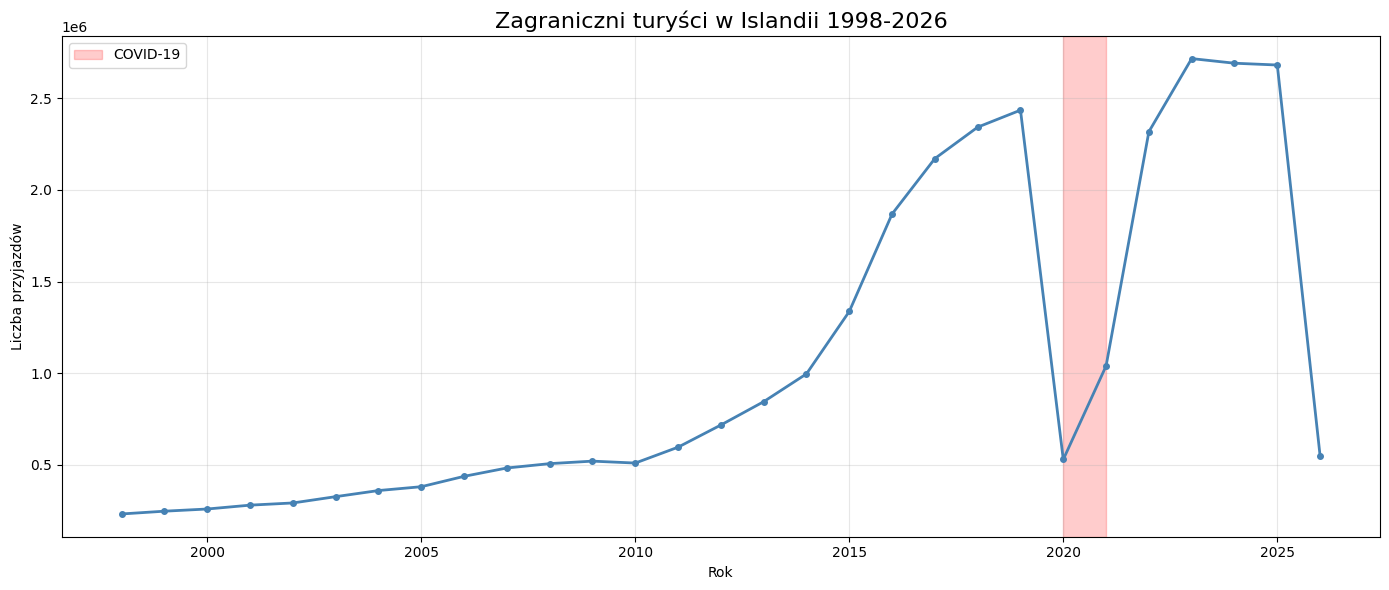

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtruj: tylko Foreigners, tylko Arrivals
df_plot = df_long[
    (df_long['Citizenship'] == 'Foreigners') & 
    (df_long['Unit'] == 'Arrivals')
].groupby('Year')['Value'].sum().reset_index()

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(df_plot['Year'], df_plot['Value'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.axvspan(2020, 2021, color='red', alpha=0.2, label='COVID-19')
plt.title('Zagraniczni turyści w Islandii 1998-2026', fontsize=16)
plt.xlabel('Rok')
plt.ylabel('Liczba przyjazdów')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/01_arrivals_trend.png', dpi=150)
plt.show()

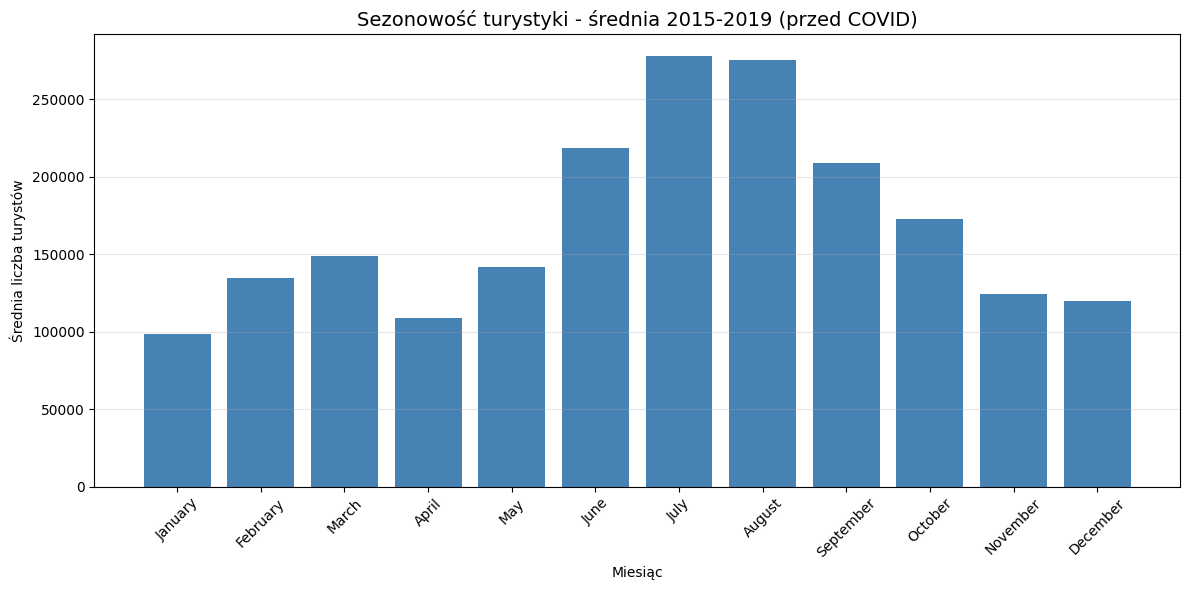

In [10]:
# Sezonowość - średnia liczba turystów wg miesiąca
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_season = df_long[
    (df_long['Citizenship'] == 'Foreigners') & 
    (df_long['Unit'] == 'Arrivals') &
    (df_long['Year'].between(2015, 2019))  # przed COVID
].groupby('Month')['Value'].mean().reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.bar(df_season['Month'], df_season['Value'], color='steelblue')
plt.title('Sezonowość turystyki - średnia 2015-2019 (przed COVID)', fontsize=14)
plt.xlabel('Miesiąc')
plt.ylabel('Średnia liczba turystów')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_seasonality.png', dpi=150)
plt.show()

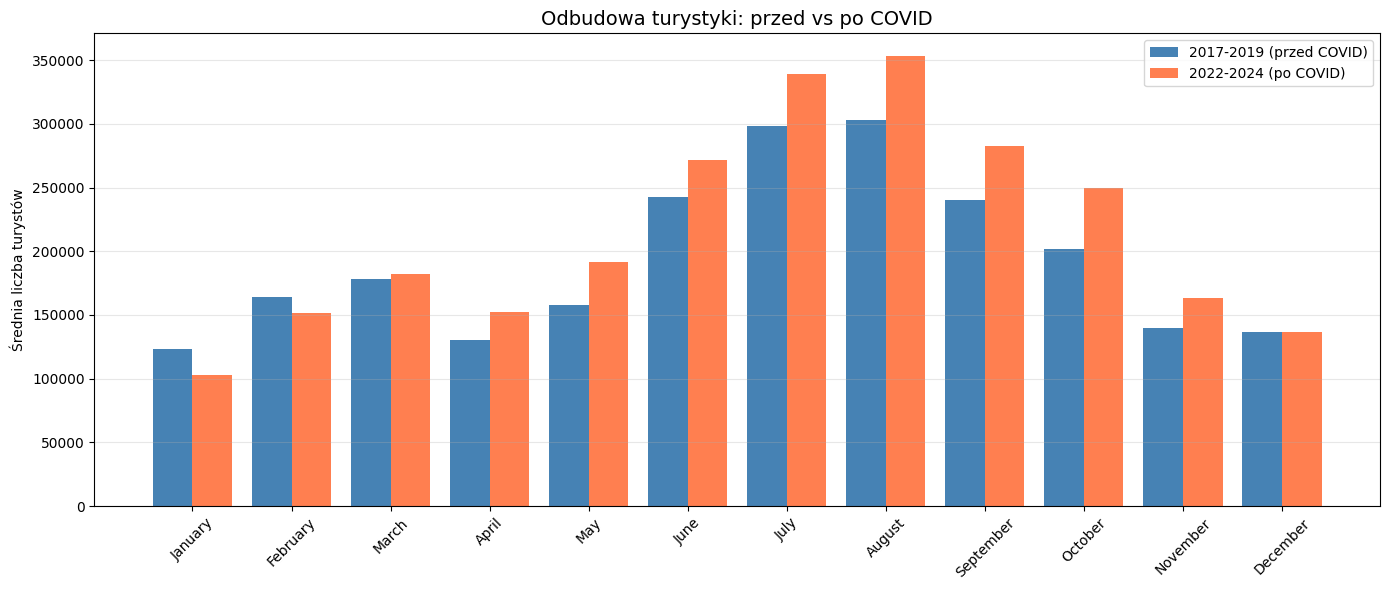

In [11]:
# Porównanie sezonowości: przed COVID vs po COVID
df_pre = df_long[
    (df_long['Citizenship'] == 'Foreigners') & 
    (df_long['Unit'] == 'Arrivals') &
    (df_long['Year'].between(2017, 2019))
].groupby('Month')['Value'].mean().reindex(month_order)

df_post = df_long[
    (df_long['Citizenship'] == 'Foreigners') & 
    (df_long['Unit'] == 'Arrivals') &
    (df_long['Year'].between(2022, 2024))
].groupby('Month')['Value'].mean().reindex(month_order)

x = range(len(month_order))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar([i - width/2 for i in x], df_pre, width, label='2017-2019 (przed COVID)', color='steelblue')
plt.bar([i + width/2 for i in x], df_post, width, label='2022-2024 (po COVID)', color='coral')
plt.title('Odbudowa turystyki: przed vs po COVID', fontsize=14)
plt.xticks(list(x), month_order, rotation=45)
plt.ylabel('Średnia liczba turystów')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/03_covid_recovery.png', dpi=150)
plt.show()

In [12]:
# ── occupancy_rate_2000 ──────────────────────────────────────
df_raw2 = pd.read_excel('../data/raw/occupancy_rate_2000.xlsx', header=None)
print("occupancy_rate - pierwsze 4 wiersze:")
df_raw2.iloc[:4, :6]

occupancy_rate - pierwsze 4 wiersze:


,0,1,2,3,4,5
0,Occupancy rate of rooms and beds in hotels 2000-,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2000,NaN,2001,NaN
3,NaN,NaN,Occupancy rate of rooms,Occupancy rate of beds,Occupancy rate of rooms,Occupancy rate of beds


In [13]:
# Oczyść occupancy rate
df_raw2 = pd.read_excel('../data/raw/occupancy_rate_2000.xlsx', header=None)

years2 = df_raw2.iloc[2, 2:].ffill()
units2 = df_raw2.iloc[3, 2:]

data2 = df_raw2.iloc[4:].copy()
data2.columns = ['Month', 'Type'] + [f"{str(y).replace('.0','')}_{u}" for y, u in zip(years2, units2)]
data2['Month'] = data2['Month'].ffill()
data2 = data2.dropna(subset=['Type'])
data2 = data2.reset_index(drop=True)

# Przekształć do formatu długiego
df_occ = data2.melt(id_vars=['Month', 'Type'], var_name='Year_Unit', value_name='Value')
df_occ[['Year', 'Unit']] = df_occ['Year_Unit'].str.split('_', n=1, expand=True)
df_occ = df_occ.drop(columns='Year_Unit')
df_occ = df_occ[df_occ['Month'] != 'Total']
df_occ['Year'] = pd.to_numeric(df_occ['Year'], errors='coerce')
df_occ['Value'] = pd.to_numeric(df_occ['Value'], errors='coerce')
df_occ = df_occ.dropna(subset=['Year', 'Value'])
df_occ['Year'] = df_occ['Year'].astype(int)

df_occ.to_csv('../data/processed/occupancy_rate_clean.csv', index=False)
print(f"Zapisano! Shape: {df_occ.shape}")
df_occ.head(6)

Zapisano! Shape: (4242, 5)


,Month,Type,Value,Year,Unit
8,January,Total,26.0,2000,Occupancy rate of rooms
9,January,East,9.7,2000,Occupancy rate of rooms
10,January,Capital region,37.0,2000,Occupancy rate of rooms
11,January,North,12.8,2000,Occupancy rate of rooms
12,January,South,9.7,2000,Occupancy rate of rooms
13,January,"West, Westfjords and Southwest to 2007",13.9,2000,Occupancy rate of rooms


In [14]:
# Oczyść hotels_guesthouses_2017
df_raw3 = pd.read_excel('../data/raw/hotels_guesthouses_2017.xlsx', header=None)
print("hotels_guesthouses - pierwsze 4 wiersze:")
df_raw3.iloc[:4, :6]

hotels_guesthouses - pierwsze 4 wiersze:


,0,1,2,3,4,5
0,Overnight stays in hotels and guesthouses 2017-,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Total,NaN,NaN,NaN,NaN
3,NaN,Total,Iceland,Foreigners,Austria,Australia


In [15]:
# Sprawdź więcej wierszy i kolumn
print("Wiersz 2:", df_raw3.iloc[2, :10].tolist())
print("Wiersz 3:", df_raw3.iloc[3, :10].tolist())
print("Wiersz 4:", df_raw3.iloc[4, :10].tolist())
print("Wiersz 5:", df_raw3.iloc[5, :10].tolist())
print("Kształt:", df_raw3.shape)

Wiersz 2: [nan, 'Total', nan, nan, nan, nan, nan, nan, nan, nan]
Wiersz 3: [nan, 'Total', 'Iceland', 'Foreigners', 'Austria', 'Australia', 'United States of America', 'Belgium', 'Brazil', 'United Kingdom']
Wiersz 4: ['2017M01', 329468, 768, 4550, 73629, 1112, 373, 96861, 67, 3338]
Wiersz 5: ['2017M02', 388450, 1519, 2141, 81819, 2177, 411, 117426, 67, 4165]
Kształt: (143, 487)


In [16]:
# Nagłówki z wiersza 3, dane od wiersza 4
countries = df_raw3.iloc[3, 1:].tolist()
data3 = df_raw3.iloc[4:].copy()
data3.columns = ['YearMonth'] + countries
data3 = data3.dropna(subset=['YearMonth'])
data3 = data3.reset_index(drop=True)

# Rozdziel YearMonth na Year i Month
data3['Year'] = data3['YearMonth'].str[:4].astype(int)
data3['Month_num'] = data3['YearMonth'].str[5:].astype(int)

month_map = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
             7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
data3['Month'] = data3['Month_num'].map(month_map)

# Przekształć do formatu długiego
df_gh = data3.melt(id_vars=['YearMonth','Year','Month_num','Month'], 
                   var_name='Country', value_name='Overnight_stays')
df_gh['Overnight_stays'] = pd.to_numeric(df_gh['Overnight_stays'], errors='coerce')
df_gh = df_gh.dropna(subset=['Overnight_stays'])
df_gh = df_gh.reset_index(drop=True)

df_gh.to_csv('../data/processed/hotels_guesthouses_clean.csv', index=False)
print(f"Zapisano! Shape: {df_gh.shape}")
df_gh.head(6)

ValueError: invalid literal for int() with base 10: 'Hote'

In [17]:
# Nagłówki z wiersza 3, dane od wiersza 4
countries = df_raw3.iloc[3, 1:].tolist()
data3 = df_raw3.iloc[4:].copy()
data3.columns = ['YearMonth'] + countries
data3 = data3.dropna(subset=['YearMonth'])
data3 = data3.reset_index(drop=True)

# Rozdziel YearMonth na Year i Month
data3['Year'] = data3['YearMonth'].str[:4].astype(int)
data3['Month_num'] = data3['YearMonth'].str[5:].astype(int)

month_map = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
             7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
data3['Month'] = data3['Month_num'].map(month_map)

# Przekształć do formatu długiego
df_gh = data3.melt(id_vars=['YearMonth','Year','Month_num','Month'], 
                   var_name='Country', value_name='Overnight_stays')
df_gh['Overnight_stays'] = pd.to_numeric(df_gh['Overnight_stays'], errors='coerce')
df_gh = df_gh.dropna(subset=['Overnight_stays'])
df_gh = df_gh.reset_index(drop=True)

df_gh.to_csv('../data/processed/hotels_guesthouses_clean.csv', index=False)
print(f"Zapisano! Shape: {df_gh.shape}")
df_gh.head(6)

ValueError: invalid literal for int() with base 10: 'Hote'

In [18]:
print(data3['YearMonth'].unique()[:10])

<StringArray>
['2017M01', '2017M02', '2017M03', '2017M04', '2017M05', '2017M06', '2017M07',
 '2017M08', '2017M09', '2017M10']
Length: 10, dtype: str


In [19]:
# Rozdziel poprawnie - format 2017M01
data3['Year'] = data3['YearMonth'].str[:4].astype(int)
data3['Month_num'] = data3['YearMonth'].str[5:].astype(int)

month_map = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
             7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
data3['Month'] = data3['Month_num'].map(month_map)

# Przekształć do formatu długiego
df_gh = data3.melt(id_vars=['YearMonth','Year','Month_num','Month'], 
                   var_name='Country', value_name='Overnight_stays')
df_gh['Overnight_stays'] = pd.to_numeric(df_gh['Overnight_stays'], errors='coerce')
df_gh = df_gh.dropna(subset=['Overnight_stays'])
df_gh = df_gh.reset_index(drop=True)

df_gh.to_csv('../data/processed/hotels_guesthouses_clean.csv', index=False)
print(f"Zapisano! Shape: {df_gh.shape}")
df_gh.head(6)

ValueError: invalid literal for int() with base 10: 'Hote'

In [20]:
df_raw3 = pd.read_excel('../data/raw/hotels_guesthouses_2017.xlsx', header=None)

countries = df_raw3.iloc[3, 1:].tolist()
data3 = df_raw3.iloc[4:].copy()
data3.columns = ['YearMonth'] + countries

# Zostaw tylko wiersze z formatem 2017M01
data3 = data3[data3['YearMonth'].astype(str).str.match(r'^\d{4}M\d{2}$')]
data3 = data3.reset_index(drop=True)

data3['Year'] = data3['YearMonth'].str[:4].astype(int)
data3['Month_num'] = data3['YearMonth'].str[5:].astype(int)

month_map = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
             7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
data3['Month'] = data3['Month_num'].map(month_map)

df_gh = data3.melt(id_vars=['YearMonth','Year','Month_num','Month'], 
                   var_name='Country', value_name='Overnight_stays')
df_gh['Overnight_stays'] = pd.to_numeric(df_gh['Overnight_stays'], errors='coerce')
df_gh = df_gh.dropna(subset=['Overnight_stays'])
df_gh = df_gh.reset_index(drop=True)

df_gh.to_csv('../data/processed/hotels_guesthouses_clean.csv', index=False)
print(f"Zapisano! Shape: {df_gh.shape}")
df_gh.head(6)

Zapisano! Shape: (40099, 6)


,YearMonth,Year,Month_num,Month,Country,Overnight_stays
0,2017M01,2017,1,January,Total,329468.0
1,2017M02,2017,2,February,Total,388450.0
2,2017M03,2017,3,March,Total,429752.0
3,2017M04,2017,4,April,Total,365034.0
4,2017M05,2017,5,May,Total,416522.0
5,2017M06,2017,6,June,Total,577401.0


In [21]:
# Sprawdź strukturę
df_raw4 = pd.read_excel('../data/raw/keflavik_passengers_2002.xlsx', header=None)
print("Keflavik - pierwsze 4 wiersze:")
df_raw4.iloc[:4, :6]

Keflavik - pierwsze 4 wiersze:


,0,1,2,3,4,5
0,Passengers through Keflavik airport by citizen...,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2002M03,2002M04,2002M05,2002M06,2002M07
3,Total Passengers,33616,35695,38770,60249,72861


In [22]:
# Wiersz 2 = daty, kolumna 0 = kraj
dates = df_raw4.iloc[2, 1:].tolist()
data4 = df_raw4.iloc[3:].copy()
data4.columns = ['Country'] + dates

# Zostaw tylko wiersze z prawdziwymi krajami
data4 = data4[data4['Country'].notna()]
data4 = data4.reset_index(drop=True)

# Przekształć do formatu długiego
df_kef = data4.melt(id_vars=['Country'], var_name='YearMonth', value_name='Passengers')
df_kef = df_kef[df_kef['YearMonth'].astype(str).str.match(r'^\d{4}M\d{2}$')]
df_kef['Year'] = df_kef['YearMonth'].str[:4].astype(int)
df_kef['Month_num'] = df_kef['YearMonth'].str[5:].astype(int)
df_kef['Month'] = df_kef['Month_num'].map(month_map)
df_kef['Passengers'] = pd.to_numeric(df_kef['Passengers'], errors='coerce')
df_kef = df_kef.dropna(subset=['Passengers'])
df_kef = df_kef.reset_index(drop=True)

df_kef.to_csv('../data/processed/keflavik_passengers_clean.csv', index=False)
print(f"Zapisano! Shape: {df_kef.shape}")
df_kef.head(6)

Zapisano! Shape: (6966, 6)


,Country,YearMonth,Passengers,Year,Month_num,Month
0,Total Passengers,2002M03,33616.0,2002,3,March
1,Iceland,2002M03,16966.0,2002,3,March
2,Foreigners,2002M03,16650.0,2002,3,March
3,U.S.A.,2002M03,4238.0,2002,3,March
4,U.K.,2002M03,3401.0,2002,3,March
5,Denmark,2002M03,1329.0,2002,3,March


In [23]:
import os
files = os.listdir('../data/processed/')
for f in files:
    path = f'../data/processed/{f}'
    df_temp = pd.read_csv(path)
    print(f"{f}: {df_temp.shape[0]} wierszy, {df_temp.shape[1]} kolumn")

hotels_guesthouses_clean.csv: 40099 wierszy, 6 kolumn
keflavik_passengers_clean.csv: 6966 wierszy, 6 kolumn
occupancy_rate_clean.csv: 4242 wierszy, 5 kolumn
overnight_stays_arrivals_clean.csv: 2034 wierszy, 5 kolumn


In [24]:
import duckdb

con = duckdb.connect()

con.execute("CREATE VIEW overnight AS SELECT * FROM read_csv_auto('../data/processed/overnight_stays_arrivals_clean.csv')")
con.execute("CREATE VIEW occupancy AS SELECT * FROM read_csv_auto('../data/processed/occupancy_rate_clean.csv')")
con.execute("CREATE VIEW passengers AS SELECT * FROM read_csv_auto('../data/processed/keflavik_passengers_clean.csv')")
con.execute("CREATE VIEW hotels AS SELECT * FROM read_csv_auto('../data/processed/hotels_guesthouses_clean.csv')")

print("Tabele załadowane!")

result = con.execute("""
    SELECT 
        Year,
        SUM(Value) as Total_Arrivals
    FROM overnight
    WHERE Citizenship = 'Foreigners'
      AND Unit = 'Arrivals'
      AND Month != 'Total'
    GROUP BY Year
    ORDER BY Total_Arrivals DESC
    LIMIT 10
""").df()

result

Tabele załadowane!


,Year,Total_Arrivals
0,2023,2716890.0
1,2024,2691701.0
2,2025,2681891.0
3,2019,2435576.0
4,2018,2342839.0
5,2022,2317940.0
6,2017,2171577.0
7,2016,1869066.0
8,2015,1337227.0
9,2021,1039802.0


In [25]:
# Zapytanie 2 - COVID impact
result2 = con.execute("""
    SELECT 
        Year,
        SUM(Value) as Total_Arrivals,
        LAG(SUM(Value)) OVER (ORDER BY Year) as Prev_Year,
        ROUND((SUM(Value) - LAG(SUM(Value)) OVER (ORDER BY Year)) 
              / LAG(SUM(Value)) OVER (ORDER BY Year) * 100, 1) as YoY_Change_Pct
    FROM overnight
    WHERE Citizenship = 'Foreigners'
      AND Unit = 'Arrivals'
      AND Month != 'Total'
    GROUP BY Year
    ORDER BY Year
""").df()

result2

,Year,Total_Arrivals,Prev_Year,YoY_Change_Pct
0,1998,232260.0,NaN,NaN
1,1999,247349.0,232260.0,6.5
2,2000,259279.0,247349.0,4.8
3,2001,280313.0,259279.0,8.1
4,2002,292262.0,280313.0,4.3
5,2003,326684.0,292262.0,11.8
6,2004,359974.0,326684.0,10.2
7,2005,380942.0,359974.0,5.8
8,2006,437561.0,380942.0,14.9
9,2007,483049.0,437561.0,10.4


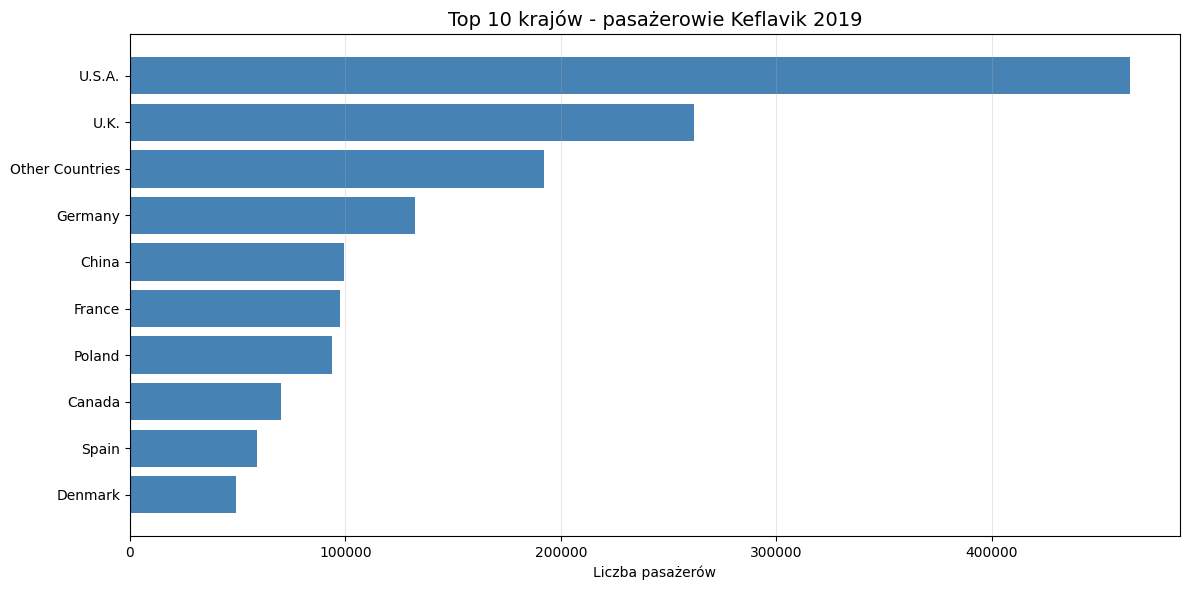

In [26]:
# Zapytanie 3 - Top 10 krajów w Keflavik 2019
result3 = con.execute("""
    SELECT 
        Country,
        SUM(Passengers) as Total_Passengers
    FROM passengers
    WHERE Year = 2019
      AND Country NOT IN ('Total Passengers', 'Foreigners', 'Iceland')
    GROUP BY Country
    ORDER BY Total_Passengers DESC
    LIMIT 10
""").df()

# Wykres
plt.figure(figsize=(12, 6))
plt.barh(result3['Country'][::-1], result3['Total_Passengers'][::-1], color='steelblue')
plt.title('Top 10 krajów - pasażerowie Keflavik 2019', fontsize=14)
plt.xlabel('Liczba pasażerów')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_top_countries.png', dpi=150)
plt.show()

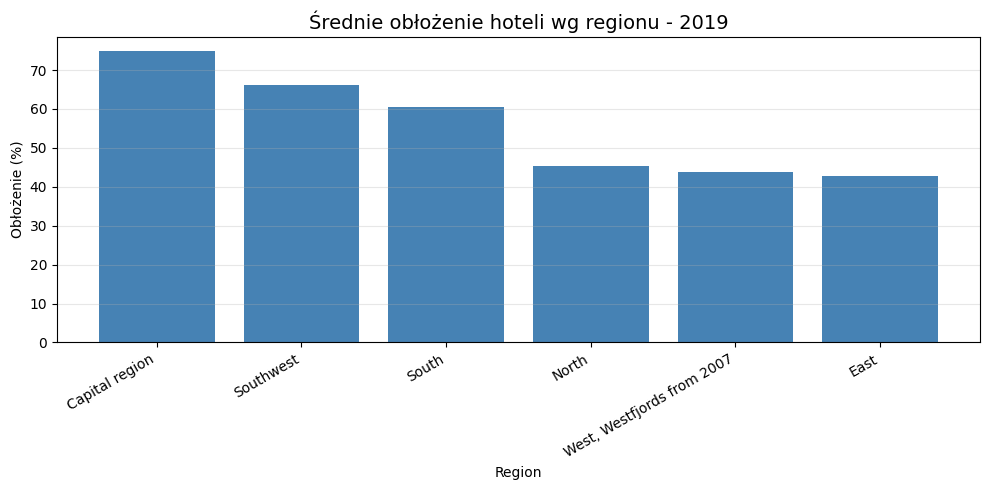

In [27]:
# Zapytanie 4 - Obłożenie wg regionu
result4 = con.execute("""
    SELECT 
        Type as Region,
        ROUND(AVG(Value), 1) as Avg_Occupancy
    FROM occupancy
    WHERE Year = 2019
      AND Unit = 'Occupancy rate of rooms'
      AND Type != 'Total'
    GROUP BY Type
    ORDER BY Avg_Occupancy DESC
""").df()

plt.figure(figsize=(10, 5))
plt.bar(result4['Region'], result4['Avg_Occupancy'], color='steelblue')
plt.title('Średnie obłożenie hoteli wg regionu - 2019', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Obłożenie (%)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_occupancy_by_region.png', dpi=150)
plt.show()